--> Dans Cell --> Run all 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os 

# Traitement de la base de données SNEE

## Instruction :

Extraire la BDD SNEE du site du ministère, ajouter s'il y a les données DU sur le même fichier mais une autre feuille Excel.

# Gestion abandon

In [4]:
#Le fichier Excel BDD
Excel_BDD=str(input("Nom du fichier Excel sur laquelle il y a la BDD : "))

Nom du fichier Excel sur laquelle il y a la BDD : BDD SNEE Brute 22-23 relu ATU.xlsx


In [5]:
#Nom du Sheet Excel
Sheet_BDD=str(input("Nom de la feuille Excel sur laquelle il y a la BDD : "))

Nom de la feuille Excel sur laquelle il y a la BDD : BDD SNEE Brute


In [6]:
#Nom du Sheet DU
Sheet_Name_DU=str(input("Nom de la feuille Excel sur laquelle il y a la BDD DU si non écrire non : "))

Nom de la feuille Excel sur laquelle il y a la BDD DU si non écrire non : DU GPEI 22-23


In [7]:
#Année Universitaire
Année=str(input("Année : "))

Année : 22-23


In [8]:
# Création du dossier
dossier="BDD "+Année
parent_dir=os.getcwd()
path=os.path.join(parent_dir,dossier)
try :
    os.mkdir(path)
except :
    print("Le dossier existe déjà")
os.chdir(parent_dir)

# Lecture du fichier Excel
BDD=pd.read_excel(Excel_BDD,sheet_name=Sheet_BDD)
BDD.columns =[column.replace(" ", "_") for column in BDD.columns]
BDD.rename(columns={'Type_de_formation_/_diplôme':'Type_de_formation','Intitulé_de_la_formation_/_diplôme':'Intitulé_de_la_formation','SIRET/RIDET':'SIRET'},inplace=True)

# Importation de la dataframe DU -> grâce à apogée
nbre_DU=0
if Sheet_Name_DU != "non" :
    DU=pd.read_excel(Excel_BDD,sheet_name=Sheet_Name_DU)
    DU.columns =[column.replace(" ", "_") for column in DU.columns]
    nbre_DU=DU["Nom"].count()
    print("Nombre de candidats DU : ",nbre_DU)
    
#Variable importante et répétitif
Genre=["Homme","Femme","non binaire"]
Type_candidature =["Candidat SNEE","SNEE Accepté"]
Type_de_formation=["Licence","Master","Doctorat","Autre"]
LMD=["Licence","Master","Doctorat"]
Fac=["Alliance","FDS","FL","FSI"]
candidature_2=["Candidat SNEE","SNEE Accepté","SNEE Refusé"]

Le dossier existe déjà
Nombre de candidats DU :  21


## Extraction des données principales de la BDD

Combien de candidat qui ont été transférées vers un autre Pépite ? 8


C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Nombre de candidats via la plateforme SNEE :  250
Nombre de SNEE accepté :  197
Nombre de souhait D2E :  125
Nombre de personnes à qui on a accordé le D2E :  34
Nombre total de candidats traités :  258


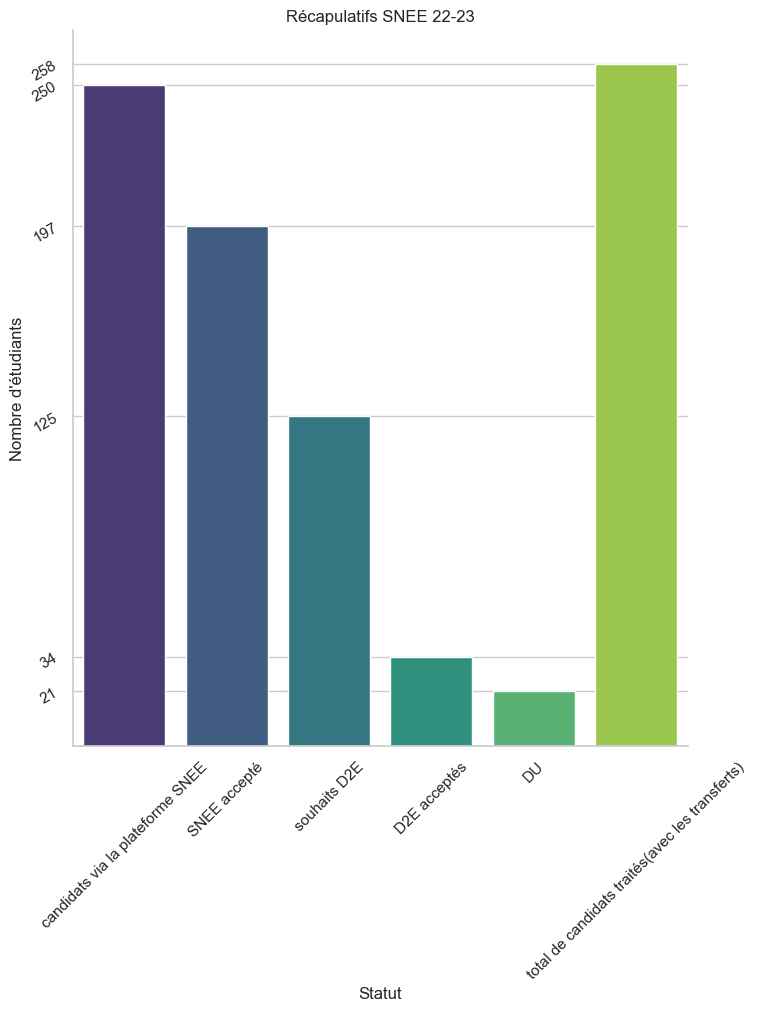

In [10]:
# Les données principales extrait du sheet BDD
nbre_Cd=BDD["Nom"].count()
nbre_SNEE=BDD[BDD.Statut_SNEE == "Accepté"]["Statut_SNEE"].count()
nbre_souhait_D2E=BDD[BDD.Souhait_D2E == "Oui"]["Souhait_D2E"].count()
nbre_accord_D2E=BDD[BDD.Accord_D2E == "Oui"]["Accord_D2E"].count()

#Donner le nombre de candidats qui ont été transféré et donc traité pour qu'il rentre dans les stats
nbre_Cd_transf=int(input("Combien de candidat qui ont été transférées vers un autre Pépite ? "))

# graphe Récapulatifs SNEE
categories = ['candidats via la plateforme SNEE', "SNEE accepté", 'souhaits D2E',"D2E acceptés","DU" ,"total de candidats traités(avec les transferts)"]
valeurs = [nbre_Cd, nbre_SNEE,nbre_souhait_D2E,nbre_accord_D2E,nbre_DU,nbre_Cd + nbre_Cd_transf]

# DataFrame Recapulatifs SNEE
Recap=pd.DataFrame([[categories[i],valeurs[i]] for i in range(len(categories))],columns=["Statut","Nombre d'étudiants"])

# Graphe SNEE avec seaborn
g = sns.catplot(kind='bar', data=Recap, x="Statut", y="Nombre d'étudiants",height=8, aspect=1,palette='viridis')
sns.set(style="whitegrid")

plt.title("Récapulatifs SNEE "+Année)
plt.xticks(rotation=45)
plt.yticks(Recap["Nombre d'étudiants"],rotation=30)
# Enregistrement du graphe au format PNG
plt.savefig(path+'/Récapulatifs SNEE '+Année+'.png',bbox_inches="tight")

# Affichage 
print("Nombre de candidats via la plateforme SNEE : ",nbre_Cd)
print("Nombre de SNEE accepté : ",nbre_SNEE)
print("Nombre de souhait D2E : ",nbre_souhait_D2E)
print("Nombre de personnes à qui on a accordé le D2E : ",nbre_accord_D2E)
print("Nombre total de candidats traités : ",nbre_Cd + nbre_Cd_transf)

## La répartition Genre

C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


          Statut        Genre  Valeur   Pourcentage parité
0  Candidat SNEE        Homme     124                49.6%
1  Candidat SNEE        Femme     126                50.4%
2  Candidat SNEE  non binaire       0                 0.0%
3   SNEE Accepté        Homme      95  48.223350253807105%
4   SNEE Accepté        Femme     102  51.776649746192895%
5   SNEE Accepté  non binaire       0                 0.0%


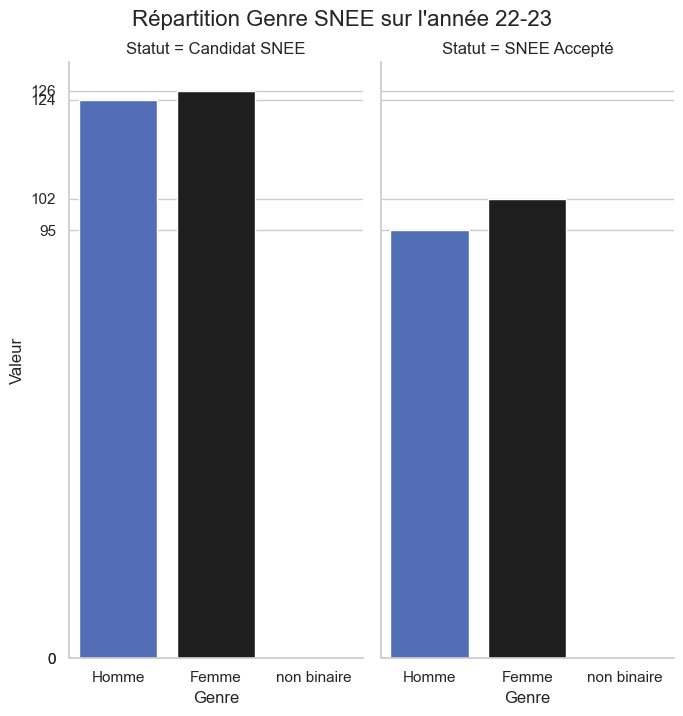

In [11]:
#Répartition Homme Femme non binaire qui ont candidaté le SNEE
nbre_Cd_H=BDD[BDD.Genre == "H"]["Genre"].count()
nbre_Cd_F=BDD[BDD.Genre == "F"]["Genre"].count()
nbre_Cd_Autre=BDD[BDD.Genre == "Autre"]["Genre"].count()


#Répartition Homme Femme non binaire qui ont le SNEE
nbre_SNEE_H=BDD[(BDD.Genre == "H") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count()
nbre_SNEE_F=BDD[(BDD.Genre == "F") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count()
nbre_SNEE_Autre=BDD[(BDD.Genre == "Autre") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count()

CD=[nbre_Cd_H,nbre_Cd_F,nbre_Cd_Autre,nbre_SNEE_H,nbre_SNEE_F,nbre_SNEE_Autre]
pourcentage=[str((nbre_Cd_H/nbre_Cd)*100)+"%",str((nbre_Cd_F/nbre_Cd)*100)+"%",str((nbre_Cd_Autre/nbre_Cd)*100)+"%",str((nbre_SNEE_H/nbre_SNEE)*100)+"%",str((nbre_SNEE_F/nbre_SNEE)*100)+"%",str((nbre_SNEE_Autre/nbre_SNEE)*100)+"%"]
Genre=["Homme","Femme","non binaire"]

# DataFrame Répartition Homme Femme non binaire
HF=pd.DataFrame({"Statut" : np.repeat(Type_candidature,len(Genre)),
                "Genre" : np.tile(Genre,len(Type_candidature)),
                "Valeur" : CD,
                "Pourcentage parité" : pourcentage})

# Graphe Répartition Homme Femme non binaire
g = sns.catplot(kind='bar', data=HF, x="Genre", y='Valeur', col='Statut',height=7, aspect=0.5,palette="icefire")
sns.set(style="whitegrid")
plt.yticks(HF["Valeur"])
plt.suptitle("Répartition Genre SNEE sur l'année "+Année, y=1.02, fontsize=16)

# Enregistrement du graphe au format PNG
plt.savefig(path+"/Répartition Genre SNEE sur l'année "+Année+'.png',bbox_inches="tight")
print(HF)

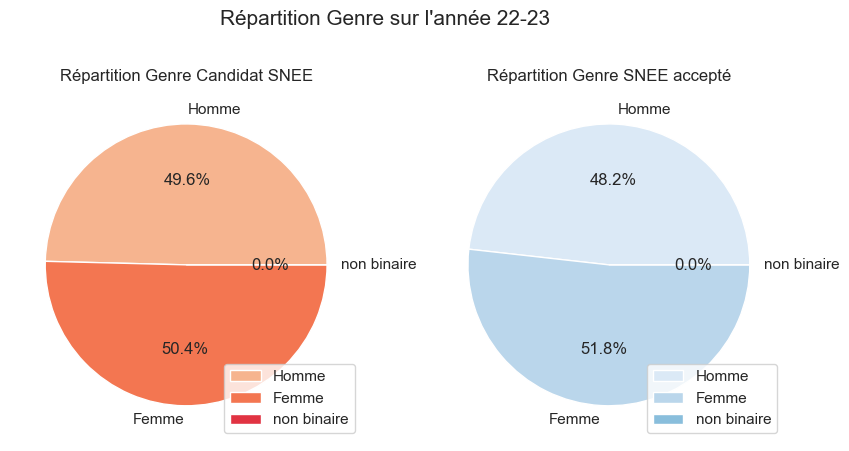

In [12]:
#Graphe camembert Répartition Homme Femme non binaire
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True) #Création de d'une grille 2x1
axes[0].pie(CD[:3],labels=Genre,autopct = '%1.1f%%',colors=sns.color_palette("rocket_r"))
axes[0].set_title("Répartition Genre Candidat SNEE")
axes[0].legend(Genre, loc="lower right")
axes[1].pie(CD[3:],labels=Genre,autopct = '%1.1f%%',colors=sns.color_palette("Blues"))
axes[1].set_title("Répartition Genre SNEE accepté")
axes[1].legend(Genre, loc="lower right")
plt.suptitle("Répartition Genre sur l'année "+Année,y=0.75 ,fontsize=15)  #Titre du graphe
plt.savefig(path+'/Répartition Genre pourcentage '+Année+'.png',bbox_inches="tight") #Enregistrement


## La répartition Licence Master(diplôme d'ingé inclus) Doctorat

In [13]:
# Données pour la construction du DataFrame

Valeurs=[BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Master LMD"or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Master LMD"or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count()]




# DataFrame Type de Formation sans les réfusés pour le graphe
TF=pd.DataFrame({"Type de formation": np.repeat(Type_de_formation,len(Genre)*len(Type_candidature)),
                "Genre" : np.tile(Genre,len(Type_candidature)*len(Type_de_formation)),
                 "statut de la candidature": np.tile(np.repeat(Type_candidature,len(Genre)),len(Type_de_formation)),
                 "Nombre" : Valeurs
                                                    })
TF
# Ancien Graphe sans couleur et moche mais simple
#palet=sns.color_palette("hls",n_colors=2)
#g = sns.catplot(kind='bar', data=TF, x="statut de la candidature", y='Nombre',hue="Genre", col='Type de formation',height=10, aspect=0.5,hue_order=["Homme","Femme"],palette=palet)
#sns.set(style="whitegrid")
#plt.yticks(TF["Nombre"])
#plt.suptitle("Répartition LMD", y=1.02, fontsize=16)

# Enregistrement du graphe au format PNG
#plt.savefig(path+'/Répartition LMD '+Année+'.png',bbox_inches="tight")



,Type de formation,Genre,statut de la candidature,Nombre
0,Licence,Homme,Candidat SNEE,14
1,Licence,Femme,Candidat SNEE,8
2,Licence,non binaire,Candidat SNEE,0
3,Licence,Homme,SNEE Accepté,10
4,Licence,Femme,SNEE Accepté,5
5,Licence,non binaire,SNEE Accepté,0
6,Master,Homme,Candidat SNEE,39
7,Master,Femme,Candidat SNEE,61
8,Master,non binaire,Candidat SNEE,0
9,Master,Homme,SNEE Accepté,30


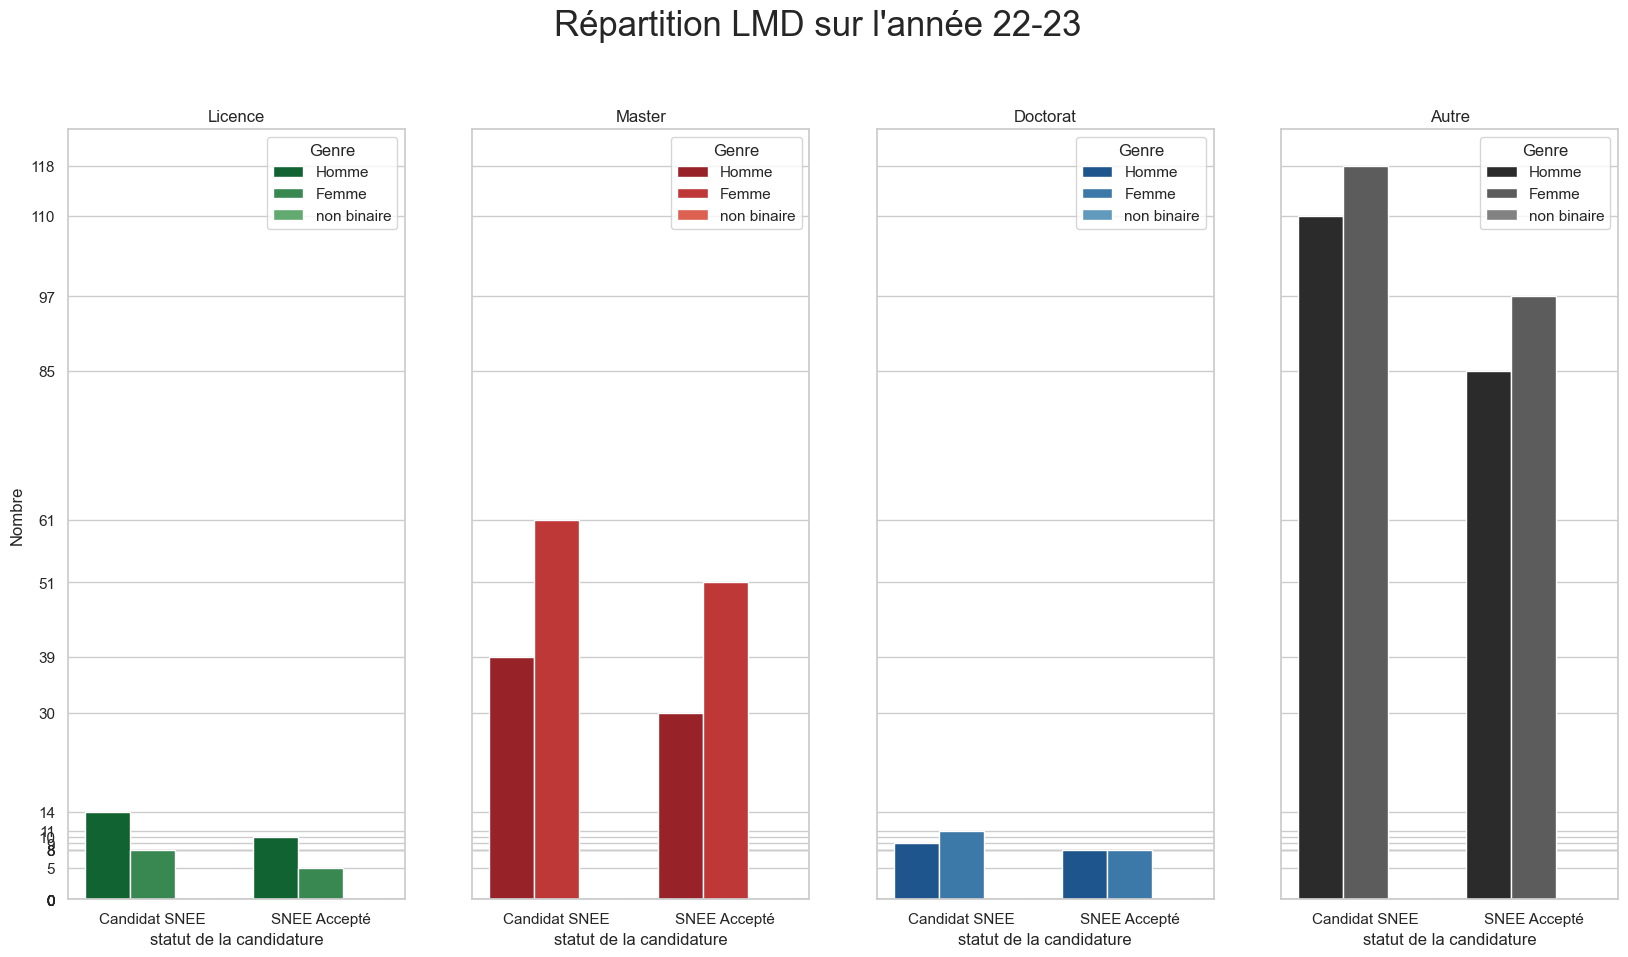

In [14]:
# Nouvelle méthode pour faire le graphe avec des plots personnaliser avec des couleurs

unique_values = TF["Type de formation"].unique()

#Création des palettes de couleurs, reversed car couleur plus visible
pal1=reversed(sns.color_palette("Greens"))
pal2=reversed(sns.color_palette("Reds"))
pal3=reversed(sns.color_palette("Blues"))
pal4=reversed(sns.color_palette("Greys"))
palette=[pal1,pal2,pal3,pal4]


#Création des subplots pour afficher chaque barbplot avec les palettes de couleurs qui vont avec
fig, axes = plt.subplots(1, len(unique_values), figsize=(20, 10), sharey=True)
for i, value in enumerate(unique_values):
    # Filtrer les données pour la valeur unique ici : le type de formation
    subset_data = TF[TF["Type de formation"] == value]
    
    # Tracer un graphique de barres avec les différentes distincions : Homme Femme et le statut de la candidature
    sns.barplot(x="statut de la candidature", y="Nombre", hue="Genre",hue_order=["Homme","Femme","non binaire"], data=subset_data, ax=axes[i], palette=palette[i])
    sns.set(style="whitegrid")
    

    # Affichage du titre de chaque grande colonne
    axes[i].set_title(value)
    if i != 0:
        axes[i].set_ylabel('')
#Affichage du nom de l'axe y qu'une fois à gauche
#axes[0].set_ylabel("Nombre")

plt.yticks(TF["Nombre"])
plt.suptitle("Répartition LMD sur l'année "+Année, y=1.0, fontsize=25)  #Titre du graphe
plt.savefig(path+'/Répartition LMD '+Année+'.png',bbox_inches="tight") #Enregistrement au format PNG
plt.show()

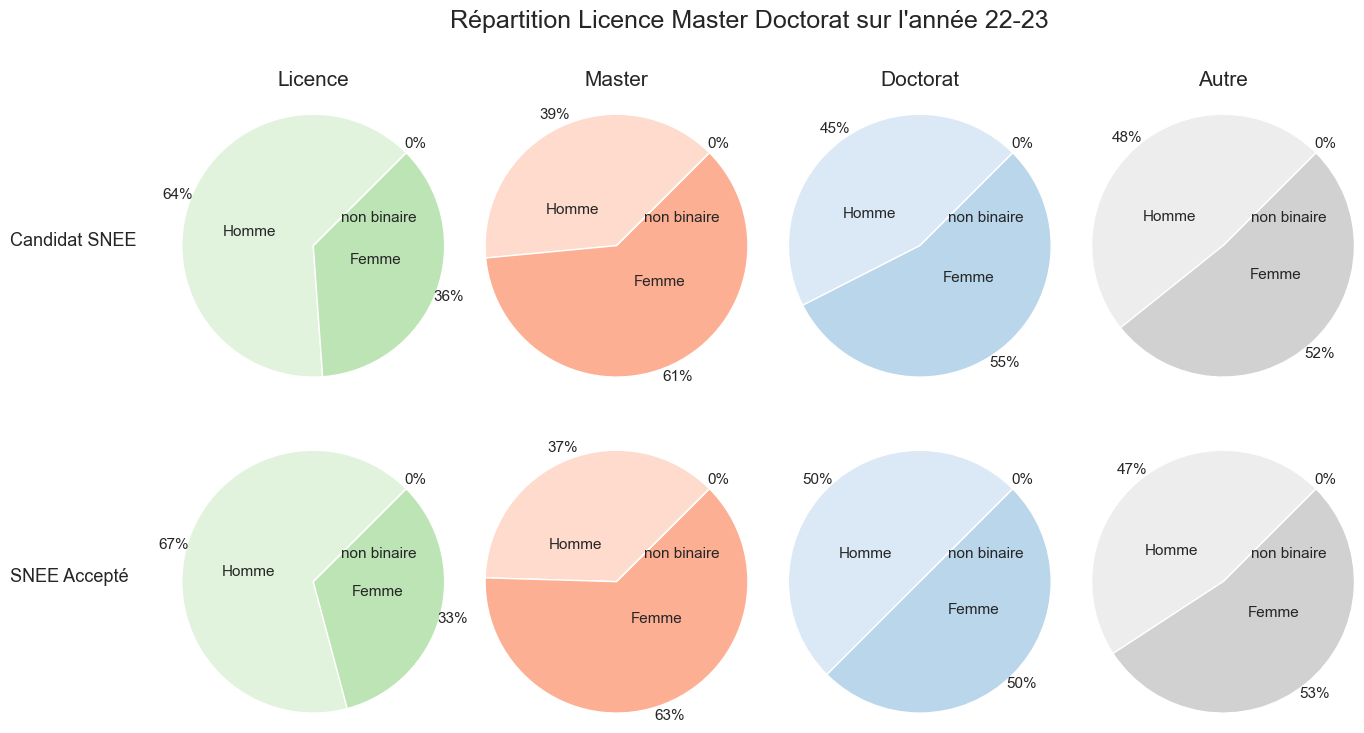

In [15]:
#Palette couleur
pal1=(sns.color_palette("Greens"))
pal2=(sns.color_palette("Reds"))
pal3=(sns.color_palette("Blues"))
pal4=(sns.color_palette("Greys"))
palette=[pal1,pal2,pal3,pal4]

#Graphe camembert Fun
fig, axes = plt.subplots(nrows=2, ncols=4,figsize=(15,8)) #Grille de graphes 4x2
for i, value in enumerate(unique_values):
    subset_data = TF[TF["Type de formation"] == value] #sous-tableau avec filtrage type de formation
    sub_sub=subset_data[subset_data["statut de la candidature"]=="Candidat SNEE"] #sous-sous-tableau avec filtrage statut de la candidature = Candidat SNEE
    
    axes[0][i].pie(sub_sub["Nombre"],labels=Genre,autopct='%1.0f%%',colors=palette[i],labeldistance=0.3,pctdistance=1.1,textprops={'fontsize': 11},radius=1.3,startangle=45)#graphe camembert
    sub_sub_1=subset_data[subset_data["statut de la candidature"]=="SNEE Accepté"]#filtrage avec SNEE Accepté
    axes[1][i].pie(sub_sub_1["Nombre"],labels=Genre,autopct='%1.0f%%',colors=palette[i],labeldistance=0.3,pctdistance=1.1,textprops={'fontsize': 11},radius=1.3,startangle=45)#graphe camembert
    axes[0][i].set_title(value,fontsize=15,y=1.1)#Pour avoir le titre seulement en haut de la première ligne, c'est la même en bas
axes[0][0].text(s="Candidat SNEE",x=-3,y=0,fontsize=13)#ajout de texte à gauche de la statut de candidature
axes[1][0].text(s="SNEE Accepté",x=-3,y=0,fontsize=13)#ajout de texte à gauche de la statut de candidature
plt.suptitle("Répartition Licence Master Doctorat sur l'année "+Année, y=1.0, fontsize=18)  #Titre du graphe
plt.savefig(path+'/Répartition LMD pourcentage '+Année+'.png',bbox_inches="tight") #Enregistrement au format PNG
plt.show()

## Répartition Fac et LMD SNEE (double filtrage)

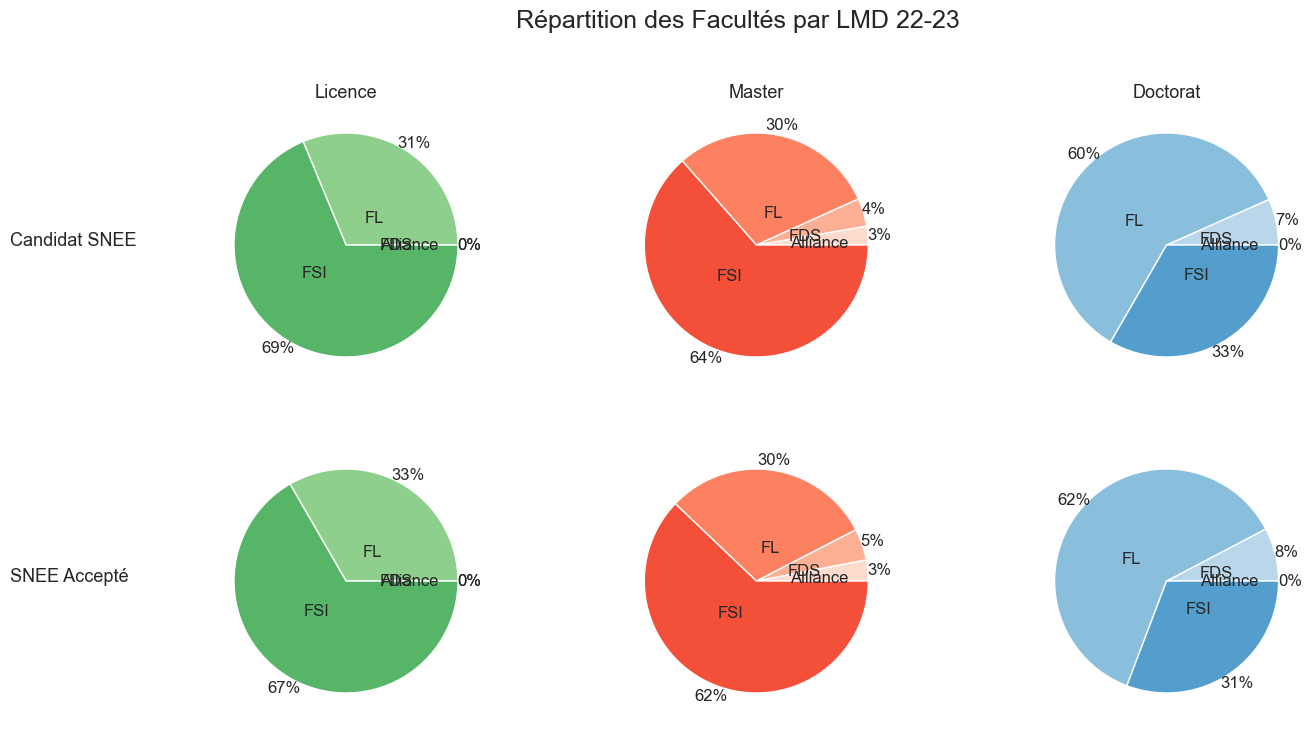

In [16]:
#DataFrame Fac et LMD croisé
try :
    Fac_LMD=pd.DataFrame({"LMD":np.tile(np.repeat(LMD,len(Fac)),len(Type_candidature)),
                     "Faculté":np.tile(np.tile(Fac,len(LMD)),len(Type_candidature)),
                      "statut de la candidature":np.repeat(np.repeat(Type_candidature,len(Fac)),len(LMD)),
                      "Nombre": [BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
                                BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "Alliance") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FDS") & (BDD.Type_de_formation == "Doctorat")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FL") & (BDD.Type_de_formation == "Doctorat")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                BDD[(BDD.Faculté == "FSI") & (BDD.Type_de_formation == "Doctorat")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
                                ]
                     }
                    )
    #Création des palettes de couleurs
    pal1=sns.color_palette("Greens")
    pal2=sns.color_palette("Reds")
    pal3=sns.color_palette("Blues")
    palette=[pal1,pal2,pal3]
    
    #Création du graphe
    fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(15, 8)) #Grille de graphe 3x2
    for i, value in enumerate(LMD):
        subset_data = Fac_LMD[Fac_LMD["LMD"] == value] #sous-tableau avec filtrage Licence Master Doctorat
        sub_sub=subset_data[subset_data["statut de la candidature"]=="Candidat SNEE"] #sous-sous-Tableau avec filtrage statut de la candidature
        axes[0][i].pie(sub_sub["Nombre"],labels=Fac,autopct='%1.0f%%',colors=palette[i],labeldistance=0.3,pctdistance=1.1,textprops={'fontsize': 12})#graphe camembert
        sub_sub_1=subset_data[subset_data["statut de la candidature"]=="SNEE Accepté"]#sous-sous-Tableau avec filtrage statut de la candidature
        axes[1][i].pie(sub_sub_1["Nombre"],labels=Fac,autopct='%1.0f%%',colors=palette[i],labeldistance=0.3,pctdistance=1.1,textprops={'fontsize': 12})#graphe camembert
        axes[0][i].set_title(value,fontsize=13)#Titre des colonnes 
    axes[0][0].text(s="Candidat SNEE",x=-3,y=0,fontsize=13)#Titre des lignes
    axes[1][0].text(s="SNEE Accepté",x=-3,y=0,fontsize=13)#Titre des lignes
    plt.suptitle("Répartition des Facultés par LMD "+Année, y=1.0, fontsize=18)  #Titre du graphe
    plt.savefig(path+'/Répartition Fac LMD pourcentage '+Année+'.png',bbox_inches="tight") #Enregistrement au format PNG    
    plt.show()
except AttributeError:
    print("Il manque la colonne Faculté dans la base de donnée, à remplir avec les valeurs : FL,FSI,Alliance,FDS.\n\U0001F609")

In [17]:
# Mise à jour avec les refusés qui apparaitront dans le tableau de la dataframe 
Valeurs_2=[BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Licence LMD"or"Licence avant LMD")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Master LMD"or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Master LMD"or "Diplôme d'ingénieur"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == ("Master LMD" or "Diplôme d'ingénieur")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == "Doctorat")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation == "Doctorat") & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat"))]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
BDD[(BDD.Genre == "H") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "F") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
BDD[(BDD.Genre == "Autre") & (BDD.Type_de_formation != ("Licence LMD"or"Licence avant LMD"or"Master LMD"or"Diplôme d'ingénieur"or"Doctorat")) & (BDD.Statut_SNEE == "Refusé")]["Nom"].count()]


TF_2=pd.DataFrame({"Type de formation": np.repeat(Type_de_formation,len(Genre)*len(candidature_2)),
                "Genre" : np.tile(Genre,len(candidature_2)*len(Type_de_formation)),
                 "statut de la candidature": np.tile(np.repeat(candidature_2,len(Genre)),len(Type_de_formation)),
                 "Nombre" : Valeurs_2
                                                    })
TF_2

,Type de formation,Genre,statut de la candidature,Nombre
0,Licence,Homme,Candidat SNEE,14
1,Licence,Femme,Candidat SNEE,8
2,Licence,non binaire,Candidat SNEE,0
3,Licence,Homme,SNEE Accepté,10
4,Licence,Femme,SNEE Accepté,5
5,Licence,non binaire,SNEE Accepté,0
6,Licence,Homme,SNEE Refusé,4
7,Licence,Femme,SNEE Refusé,3
8,Licence,non binaire,SNEE Refusé,0
9,Master,Homme,Candidat SNEE,39


## Répartition par Faculté

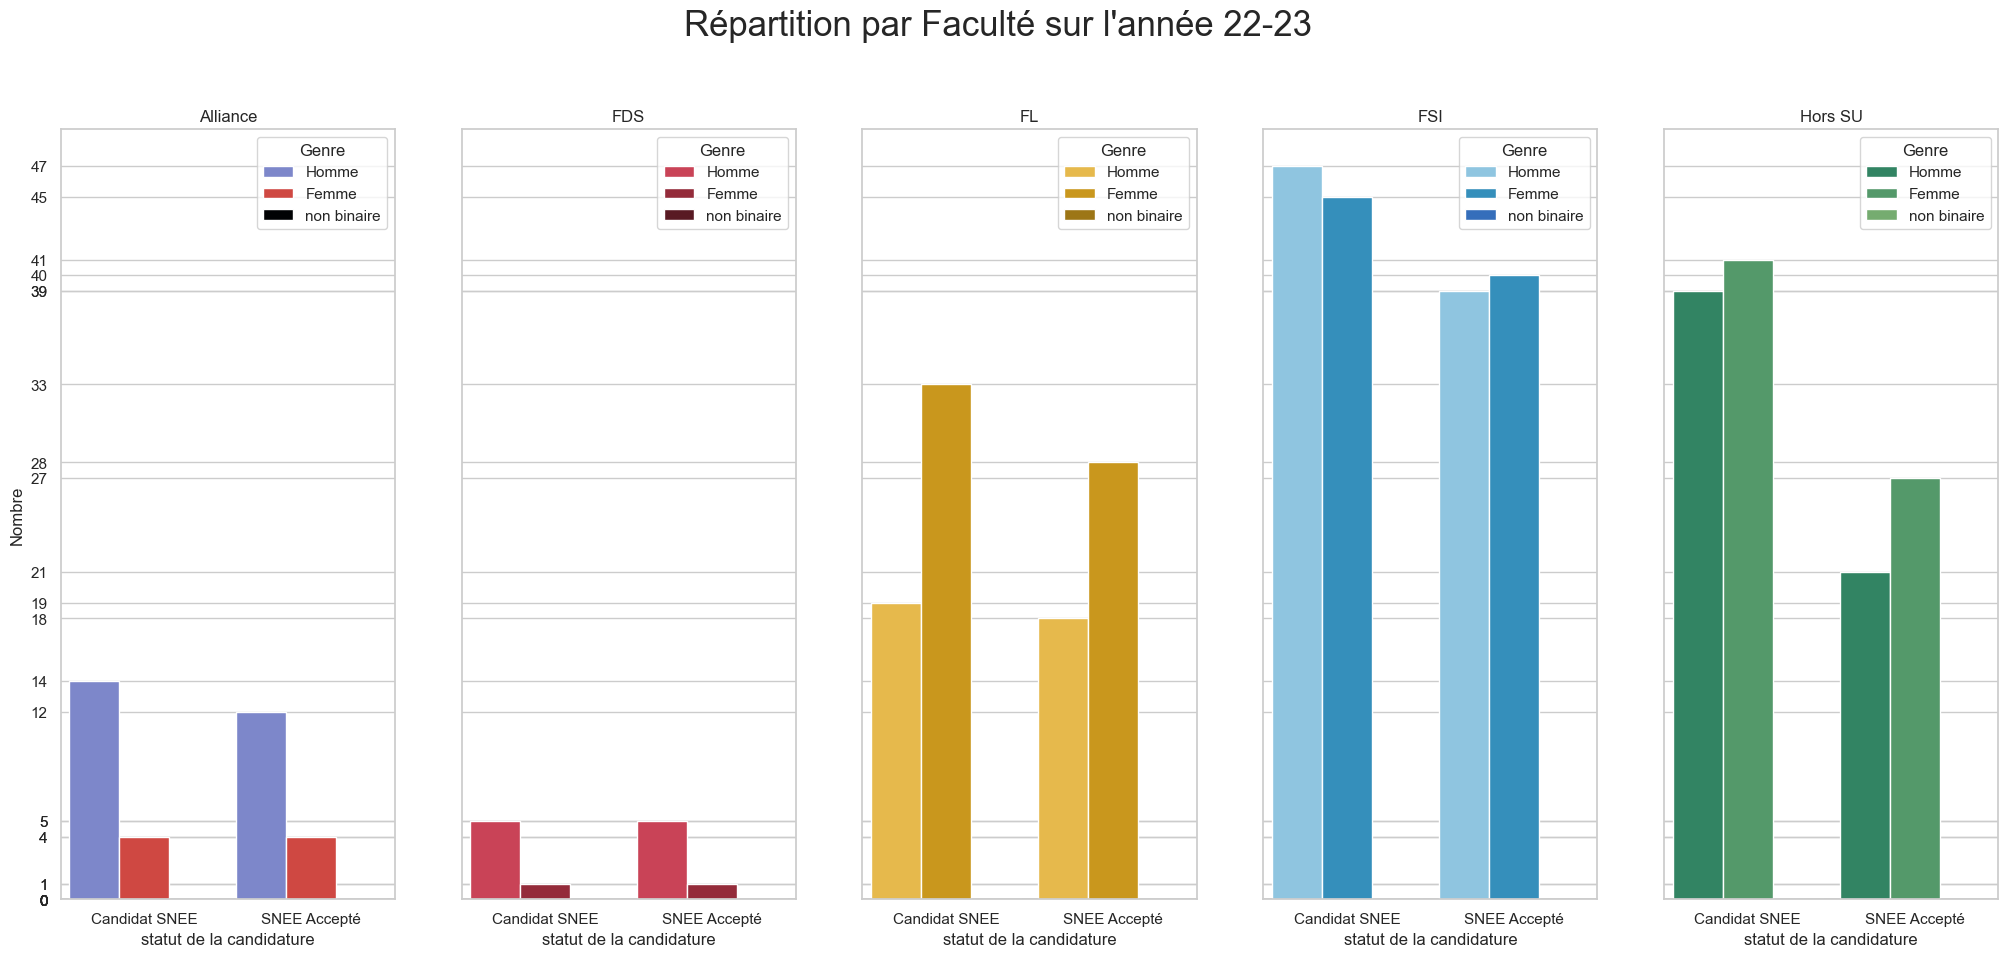

In [18]:



#DataFrame avec les différentes facultés
try :
#Données pour la construction du DataFrame
    Facu=["Alliance","FDS","FL","FSI","Hors SU"]

    Valeurs=[BDD[(BDD.Genre == "H") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    ]
    
    Valeurs_2=[BDD[(BDD.Genre == "H") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Alliance")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FDS")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FL")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FSI")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Hors SU")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Accepté")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "H") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "F") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Alliance")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FDS")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FL")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "FSI")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count(),
    BDD[(BDD.Genre == "Autre") & (BDD.Faculté == "Hors SU")& (BDD.Statut_SNEE == "Refusé")]["Nom"].count()
    ]
    
    Data_Fac=pd.DataFrame({"Genre": np.tile(np.repeat(Genre,len(Facu)),len(Type_candidature)),
                "Faculté" : np.tile(np.tile(Facu,len(Genre)),len(Type_candidature)),
                 "statut de la candidature" : np.repeat(Type_candidature,len(Genre)*len(Facu)),
                "Nombre" : Valeurs
                          })
    Data_Fac2=pd.DataFrame({"Genre": np.tile(np.repeat(sorted(Genre),len(Facu)),len(candidature_2)),
                "Faculté" : np.tile(np.tile(Facu,len(Genre)),len(candidature_2)),
                 "statut de la candidature" : np.repeat(candidature_2,len(Genre)*len(Facu)),
                "Nombre" : Valeurs_2
                          })

    # Même méthode
    unique_values = Data_Fac["Faculté"].unique()

    #Palette de couleurs
    paly=["#ffc433","#e6a300","#b37f00"]
    palr=["#df2d47","#a6192e","#640f1c"]
    palb=["#82caed","#1f97d1","#1f6bd1"]
    pala=["#707dd7","#e6332a","#010204"]
    palette=[pala,palr,paly,palb,sns.color_palette("summer")]

    # Création des plots
    fig, axes = plt.subplots(1, len(unique_values), figsize=(25, 10), sharey=True)
    for i, value in enumerate(unique_values):
        # Filtrer les données pour la valeur unique
        subset_data = Data_Fac[Data_Fac["Faculté"] == value]
        
        # Tracer un graphique de barres pour la sous-ensemble de données actuel
        sns.barplot(x="statut de la candidature", y="Nombre", hue="Genre",hue_order=["Homme","Femme","non binaire"], data=subset_data, ax=axes[i], palette=palette[i],width=0.9)
        sns.set(style="whitegrid")
        # Ajouter un titre au sous-graphique
        axes[i].set_title(value)
        axes[i].set_title(value)
        if i != 0:
            axes[i].set_ylabel('')
    plt.yticks(Data_Fac["Nombre"])
    plt.suptitle("Répartition par Faculté sur l'année "+Année, y=1.0, fontsize=25)
    plt.savefig(path+'/Répartition par Faculté '+Année+'.png',bbox_inches="tight")
except AttributeError:
    print("Il manque la colonne Faculté dans la base de donnée, à remplir avec les valeurs : FL,FSI,Alliance,FDS.\n\U0001F609")
#Ancien Graphe moche sans couleur mais plus simple
#g = sns.catplot(kind='bar', data=Data_Fac, x="statut de la candidature", y='Nombre',hue="Genre", col='Faculté',height=8, aspect=0.4,hue_order=["Homme","Femme"],palette=palet)
#sns.set(style="whitegrid")
#plt.yticks(Data_Fac["Nombre"])
#plt.suptitle("Répartition Faculté", y=1.02, fontsize=16)
#g.set_titles("Faculté {col_name}")

# Enregistrement du graphe au format PNG
#plt.savefig(path+'/Répartition Faculté '+Année+'.png',bbox_inches="tight")





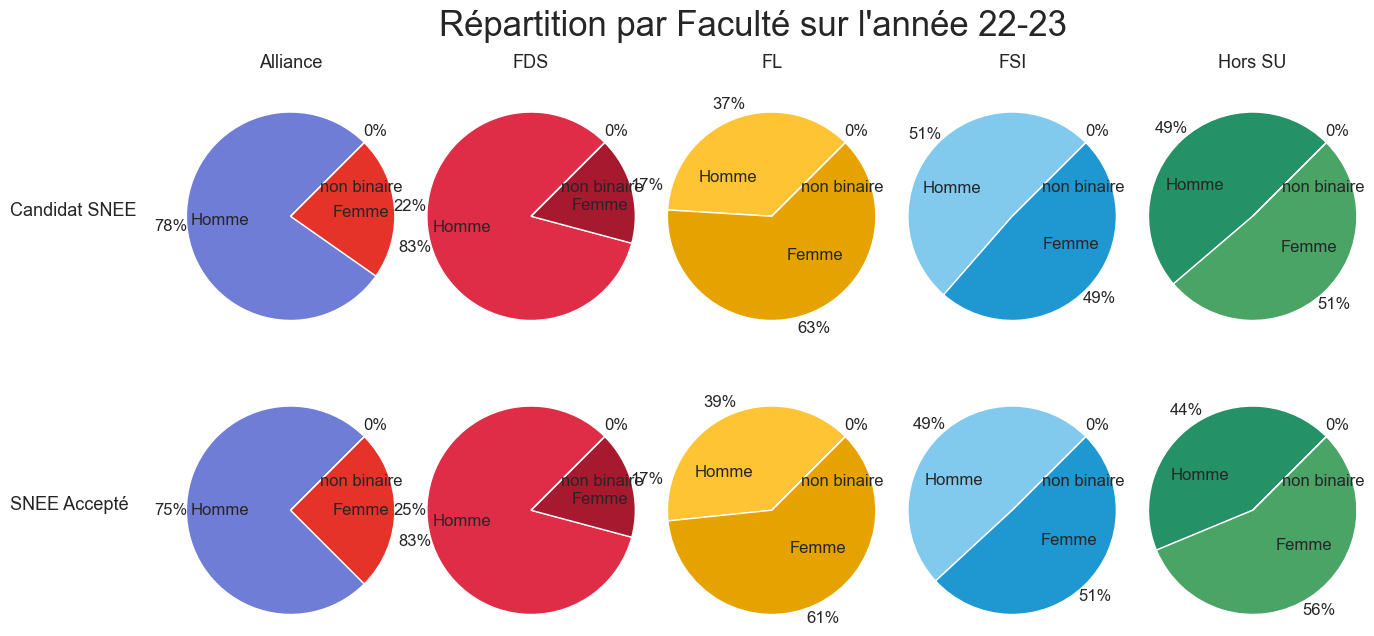

In [19]:
try:
    
    fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 7))
    for i, value in enumerate(Facu):
        subset_data = Data_Fac[Data_Fac["Faculté"] == value]
        sub_sub=subset_data[subset_data["statut de la candidature"]=="Candidat SNEE"]
        axes[0][i].pie(sub_sub["Nombre"],labels=Genre,autopct='%1.0f%%',colors=palette[i],labeldistance=0.4,pctdistance=1.15,textprops={'fontsize': 12},radius=1.3,startangle=45)
        sub_sub_1=subset_data[subset_data["statut de la candidature"]=="SNEE Accepté"]
        axes[1][i].pie(sub_sub_1["Nombre"],labels=Genre,autopct='%1.0f%%',colors=palette[i],labeldistance=0.4,pctdistance=1.15,textprops={'fontsize': 12},radius=1.3,startangle=45)
        axes[0][i].set_title(value,fontsize=13,y=1.2)
    axes[0][0].text(s="Candidat SNEE",x=-3.5,y=0,fontsize=13)
    axes[1][0].text(s="SNEE Accepté",x=-3.5,y=0,fontsize=13)
    plt.suptitle("Répartition par Faculté sur l'année "+Année, y=1.0, fontsize=25)
    plt.savefig(path+'/Répartition par Faculté pourcentage '+Année+'.png',bbox_inches="tight")
    plt.show()
except KeyError:
    print("Il manque la colonne Faculté dans la base de donnée, à remplir avec les valeurs : FL,FSI,Alliance,FDS.\n\U0001F609")

## Répartition par secteur

                 Secteur  Nombre
0        Culture, Médias      44
1   Technologies vertes       26
2              Bien-être      25
3   Digital et Objets co      24
4   Alimentation et Agro      23
5   Technologies médical      21
6   Services, Formation,      21
7           Design, Mode      20
8   Education et Enfance      12
9                 Sports       9
10  Economie Sociale et        7
11    Finance, Juridique       7
12   Ressources humaines       6
13  Habitat et Ville int       3
14    Energie et Telecom       2


C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


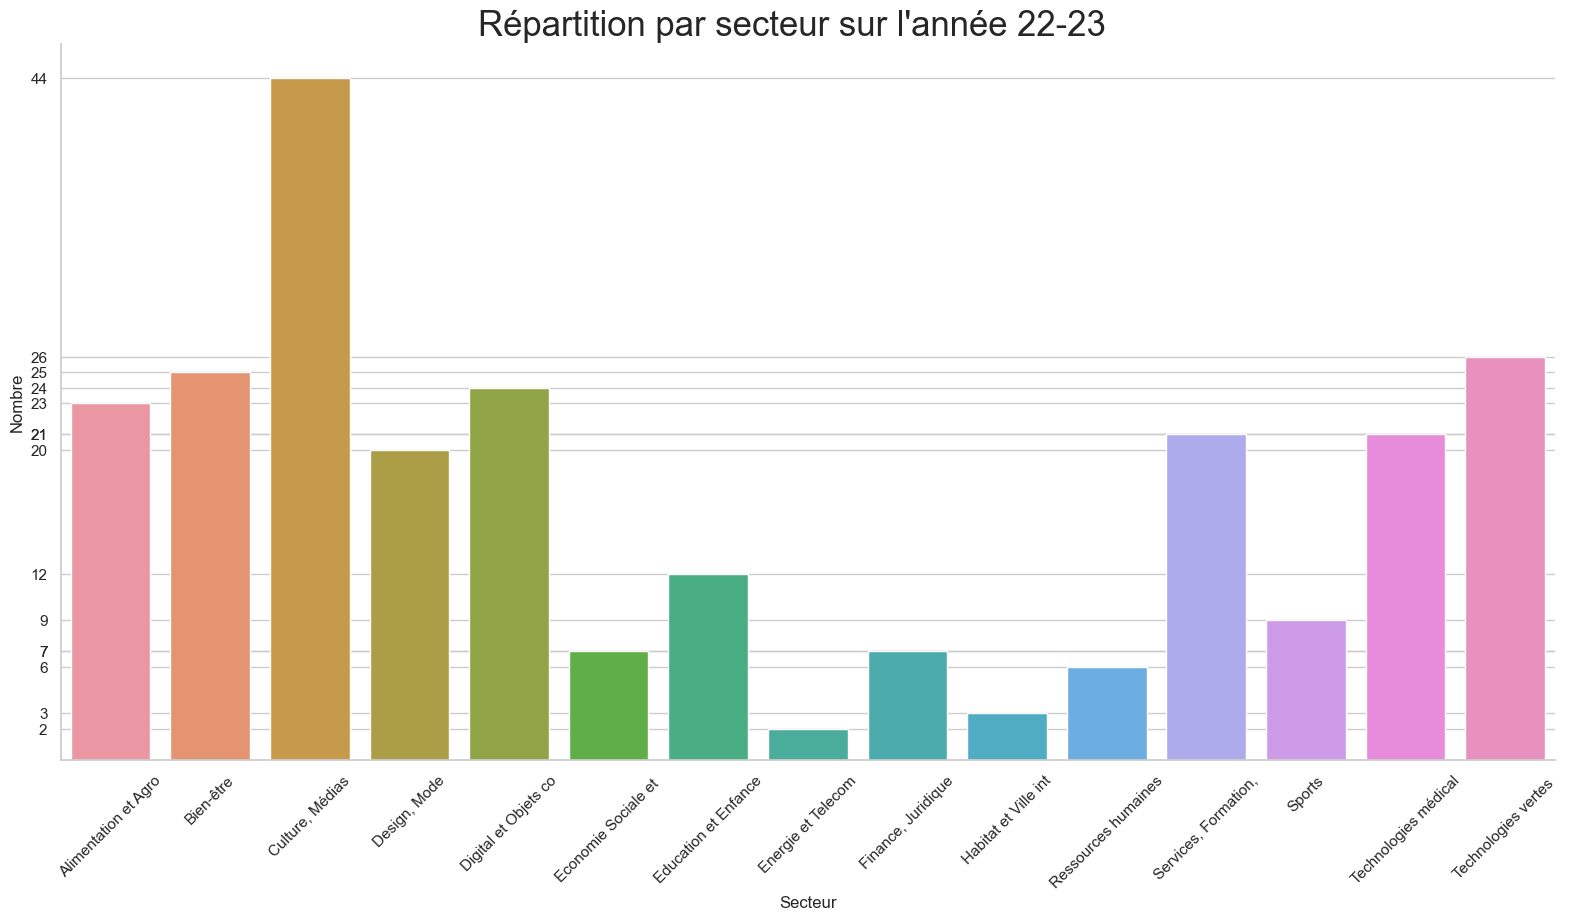

In [20]:
# Répartition par secteur
Secteur=pd.DataFrame(BDD["Secteur"].value_counts()).reset_index()
Secteur.rename(columns={"count":"Nombre"},inplace=True)
print(Secteur)
g = sns.catplot(kind='bar', data=Secteur, x="Secteur", y='Nombre',height=8, aspect=2,order=sorted(list(Secteur["Secteur"].unique())))
sns.set(style="whitegrid")
plt.yticks(Secteur["Nombre"])
plt.suptitle("Répartition par secteur sur l'année "+Année, y=1.02, fontsize=25)
plt.xticks(rotation=45)
plt.savefig(path+'/Répartition par secteur '+Année+'.png',bbox_inches="tight")

250
                                  Secteur  Nombre
0                    Alimentation et Agro      23
1   Autre secteurs qui font moins de 3.6%      25
2                               Bien-être      25
3                         Culture, Médias      44
4                            Design, Mode      20
5                    Digital et Objets co      24
6                    Education et Enfance      12
7                    Services, Formation,      21
8                                  Sports       9
9                    Technologies médical      21
10                   Technologies vertes       26


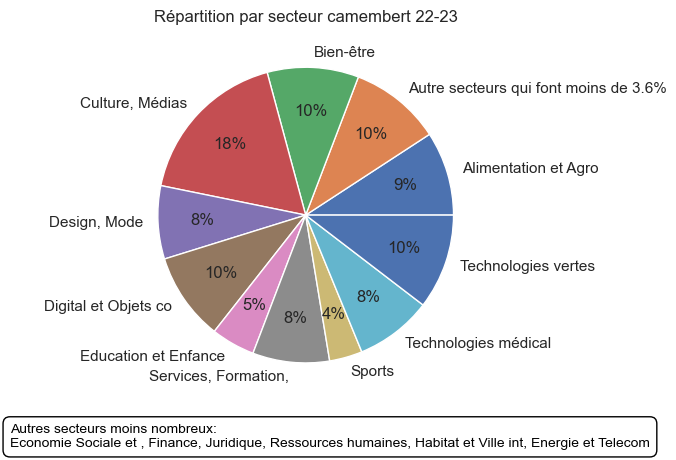

In [73]:
Secteur_draw=pd.DataFrame()
S=Secteur.sort_values(by="Nombre",ascending=False).loc[9,"Nombre"]
Secteur_draw=Secteur.copy()
Tot_secteur=sum(Secteur["Nombre"])
print(Tot_secteur)
L=list(Secteur_draw.loc[Secteur["Nombre"] < S,"Secteur"])

Secteur_draw.loc[Secteur["Nombre"] < S,"Secteur"] = "Autre secteurs qui font moins de "+str(100*S/Tot_secteur)+"%"
Secteur_draw = Secteur_draw.groupby('Secteur')['Nombre'].sum().reset_index()
print(Secteur_draw)
plt.pie(Secteur_draw["Nombre"], labels=Secteur_draw['Secteur'], autopct='%.0f%%',labeldistance=1.10,pctdistance=0.7)
plt.title("Répartition par secteur camembert "+Année)
autres_label = "Autres secteurs moins nombreux:\n" + ", ".join(list(L))
plt.text(-2, -1.5, autres_label, fontsize=10, color='black', verticalalignment='center', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.5'))
plt.savefig(path+'/Répartition par secteur pourcentage '+Année+'.png',bbox_inches="tight")
plt.show()

In [22]:
#Date d'envoie des candidatures
dates = pd.to_datetime(BDD["Envoi"])
BDD['year'] = dates.dt.year
BDD['month'] = dates.dt.month

#On compte le nombre de fois qu'apparaît le même mois et année(les 2 liés) pour compter le nombre de candidatures par mois
comptage = pd.DataFrame(BDD[['month','year']].value_counts()).reset_index()
#On trie dans l'ordre chronologique (plus ancien au plus récent)
comptage = comptage.sort_values(by="month",ascending=True).sort_values(by="year",ascending=True)
# Création d'une colonne en plus qui regroupe le mois et l'année, c'est plus simple de trier de cette façon 
comptage["Mois"]=comptage["month"].astype(str)+'-'+comptage["year"].astype(str)
comptage.rename(columns={"count":"Nombre"},inplace=True)
comptage

,month,year,Nombre,Mois
13,11,2021,1,11-2021
9,3,2022,5,3-2022
11,4,2022,3,4-2022
12,5,2022,1,5-2022
0,6,2022,44,6-2022
4,7,2022,27,7-2022
8,8,2022,10,8-2022
1,9,2022,38,9-2022
2,10,2022,37,10-2022
6,11,2022,14,11-2022


In [23]:
# Comité Même procédé pour voir le nombre d'étudiants passant en comité et de comité par mois
comité=pd.DataFrame(BDD[["Comité_d'engagement","Date_du_Comité_d'engagement"]].value_counts()).reset_index()
comité=comité.sort_values(by="Date_du_Comité_d'engagement")[:-1].reset_index()
comité

,index,Comité_d'engagement,Date_du_Comité_d'engagement,count
0,14,Comité 1 13 juin 202,2022-06-13,7
1,5,Comité 2 17 juin 202,2022-06-17,13
2,10,Comité 3 8 Juillet 2,2022-07-08,9
3,13,Comité 4 12 juillet,2022-07-12,8
4,21,Comité 5 13 juillet,2022-07-13,5
5,8,Comité 6 7 septembre,2022-09-07,9
6,15,Comité 7 9 Septembre,2022-09-09,7
7,6,Comité 8 13 septembr,2022-09-13,11
8,7,Comité 9 22 septembr,2022-09-22,10
9,17,Comité 10 29 septemb,2022-09-29,7


In [24]:
# Comité Même procédé pour voir le nombre d'étudiants passant en comité et de comité par mois
#comité=pd.DataFrame(BDD[["Comité_d'engagement","Date_du_Comité_d'engagement"]].value_counts()).reset_index()
comité["Année"]=pd.to_datetime(comité["Date_du_Comité_d'engagement"]).dt.year
comité["mois"]=pd.to_datetime(comité["Date_du_Comité_d'engagement"]).dt.month
Nb_comité=pd.DataFrame(comité[["Année","mois"]].value_counts()).reset_index()
Nb_comité.rename(columns={"count":"Nombre_comité"},inplace=True)
Nb_comité["Mois"]=Nb_comité["mois"].astype(str)+'-'+Nb_comité["Année"].astype(str)
Nb_comité=Nb_comité.sort_values(by="mois",ascending=True).sort_values(by="Année",ascending=True)

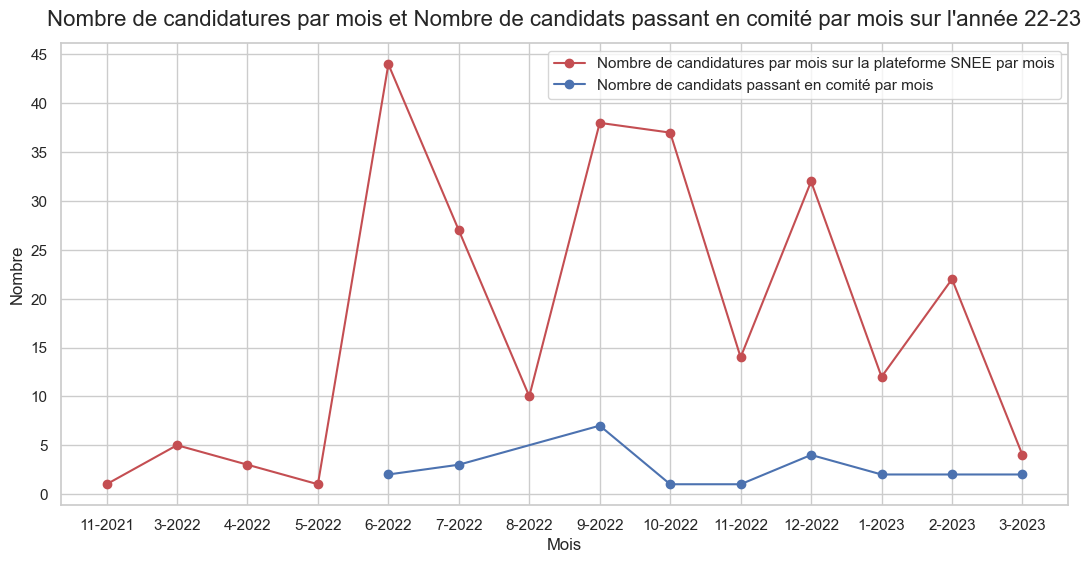

In [25]:
# là c'est le nombre de passage en comité
dates = pd.to_datetime(comité["Date_du_Comité_d'engagement"])
comité_2=pd.DataFrame()
comité_2["Année"]=dates.dt.year
comité_2["mois"]=dates.dt.month
comi=pd.DataFrame(comité_2.value_counts()).reset_index()
comi=comi.sort_values(by="mois",ascending=True).sort_values(by="Année",ascending=True)
comi["Mois"]=comi["mois"].astype(str)+'-'+comi["Année"].astype(str)
comi.rename(columns={"count":"Nombre"},inplace=True)

#graphe 1
fig,ax=plt.subplots(figsize=(13,6))
ax.plot(comptage["Mois"], comptage["Nombre"], '-ro', label='Nombre de candidatures par mois sur la plateforme SNEE par mois')
ax.plot(comi["Mois"],comi["Nombre"],'-bo',label="Nombre de candidats passant en comité par mois")
plt.title("Nombre de candidatures par mois et Nombre de candidats passant en comité par mois sur l'année "+Année,y=1.02, fontsize=16)
plt.legend()
plt.yticks(range(0,max(comi["Nombre"].max(),comptage["Nombre"].max())+5,5))
plt.ylabel("Nombre")
plt.xlabel("Mois")
plt.savefig(path+"/Comités et candidatures "+Année+'.png',bbox_inches="tight")
plt.show()



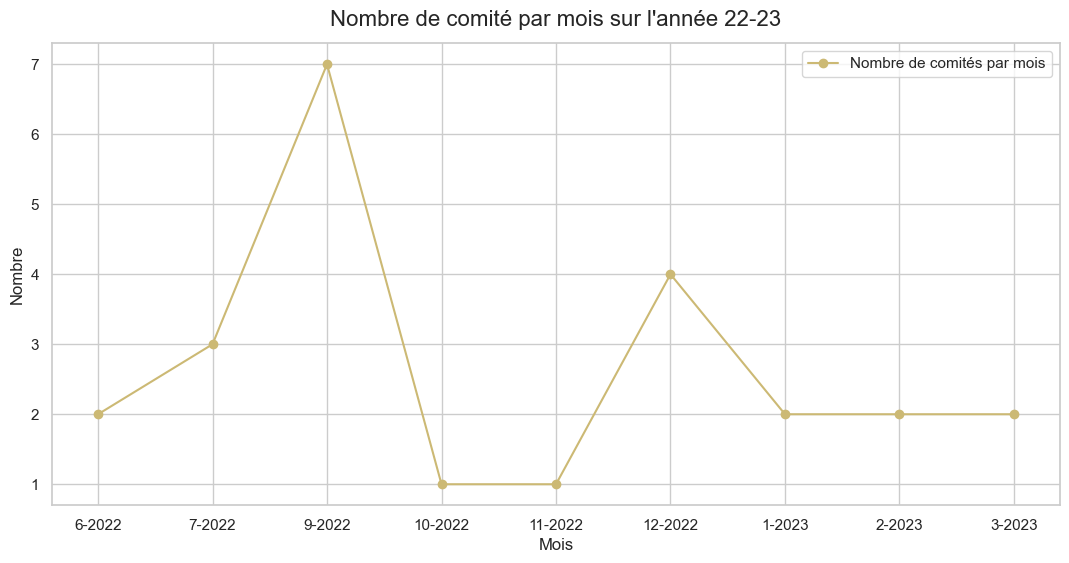

In [26]:
#graphe 2
fig,ax2=plt.subplots(figsize=(13,6))
ax2.plot(Nb_comité["Mois"],Nb_comité["Nombre_comité"],'-yo',label="Nombre de comités par mois")
plt.title("Nombre de comité par mois sur l'année "+Année,y=1.02, fontsize=16)
plt.ylabel("Nombre")
plt.xlabel("Mois")
plt.legend()
plt.savefig(path+"/Nombre de comités "+Année+'.png',bbox_inches="tight")
plt.show()

C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


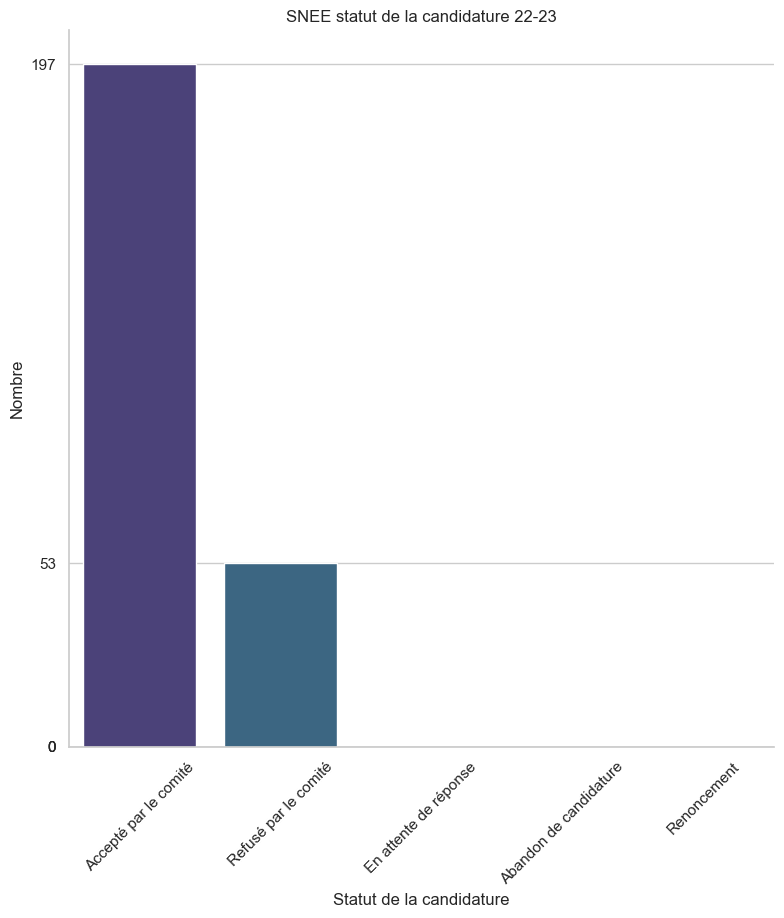

  Statut de la candidature  Nombre
0    Accepté par le comité     197
1     Refusé par le comité      53
2    En attente de réponse       0
3   Abandon de candidature       0
4              Renoncement       0
0.0%


In [27]:
#Abandonnée


Gestion_SNEE={"Statut de la candidature":["Accepté par le comité","Refusé par le comité","En attente de réponse","Abandon de candidature","Renoncement"],
             "Nombre":[BDD[BDD.Statut_SNEE == "Accepté"]["Nom"].count(),BDD[(BDD.Statut_SNEE == "Refusé") & (BDD.Abandonnée == "Non")]["Nom"].count(),
                      BDD[BDD.Statut_SNEE == "En attente"]["Nom"].count(),BDD[(BDD.Statut_SNEE == "Refusé") & (BDD.Abandonnée =="Oui")]["Nom"].count(),BDD[BDD.Statut_SNEE == "Renoncement"]["Nom"].count()]}

SNEE_statut_de_la_candidature = pd.DataFrame(Gestion_SNEE)
g = sns.catplot(kind='bar', data=SNEE_statut_de_la_candidature, x="Statut de la candidature", y="Nombre",height=8, aspect=1,palette='viridis')
sns.set(style="whitegrid")
plt.yticks(SNEE_statut_de_la_candidature["Nombre"])
plt.title("SNEE statut de la candidature "+Année)
plt.xticks(rotation=45)
plt.savefig(path+"/SNEE statut de la candidature "+Année+'.png',bbox_inches="tight")
plt.show()
print(SNEE_statut_de_la_candidature)
print(str((Gestion_SNEE["Nombre"][-1]+Gestion_SNEE["Nombre"][-2])/nbre_Cd)+"%")

## Export Excel

In [28]:
# Exportation au format Excel avec les différents Sheets
with pd.ExcelWriter(path+'/Recap BDD SNEE '+Année+'.xlsx') as writer:  
    Recap.to_excel(writer, sheet_name='Recap '+Année,index=False)
    HF.to_excel(writer, sheet_name='Répartition Homme Femme '+Année,index=False)
    TF_2.to_excel(writer, sheet_name='Répartition LMD '+Année,index=False)
    Secteur.to_excel(writer, sheet_name="Répartition par Secteur "+Année,index=False)
    comptage[["Mois","Nombre"]].to_excel(writer, sheet_name="Nombre de candidatures par mois "+Année,index=False)
    Nb_comité[["Nombre_comité","Mois"]].to_excel(writer, sheet_name="Nombre de comité par mois "+Année,index=False)
    comi[["Nombre","Mois"]].to_excel(writer, sheet_name="Nombre d'étudiants passant en comité par mois "+Année,index=False)
    SNEE_statut_de_la_candidature.to_excel(writer,sheet_name="statut de la candidature"+Année,index=False)
    try :
        Fac_LMD.to_excel(writer,sheet_name="Répartition Faculté et LMD"+Année,index=False)
        Data_Fac2.to_excel(writer, sheet_name='Répartition Faculté '+Année,index=False)
    except NameError:
        print("pas de colonne Faculté donc pas de graphe Faculté ni de feuille Excel")
print("Vos fichiers se trouvent dans le dossier suivant : ",path)

Vos fichiers se trouvent dans le dossier suivant :  C:\Users\rajendram\BDD 22-23


C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
C:\Users\rajendram\AppData\Local\anaconda3\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


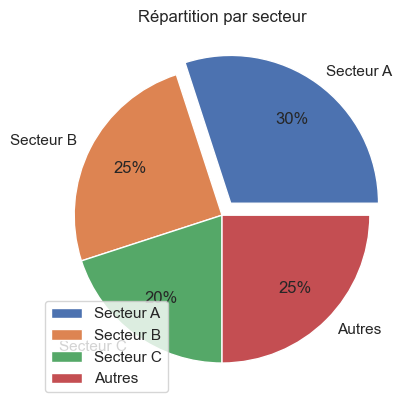

In [71]:
import matplotlib.pyplot as plt

# Données de test
Secteur_draw = pd.DataFrame({
    'Secteur': ['Secteur A', 'Secteur B', 'Secteur C', 'Autres'],
    'Nombre': [30, 25, 20, 25]
})

# Définir les pourcentages d'explosion
explode = (0.1, 0, 0, 0)  # Explosion de la première tranche

# Créer le graphique en camembert
patches, texts, autotexts = plt.pie(Secteur_draw["Nombre"], labels=Secteur_draw['Secteur'], autopct='%.0f%%', labeldistance=1.10, pctdistance=0.7, explode=explode)

# Ajouter un titre
plt.title("Répartition par secteur")

# Ajouter une légende personnalisée pour la part "Autres"
plt.legend(patches, Secteur_draw['Secteur'], loc="lower left")

# Afficher le graphique
plt.show()